In [7]:
# DS4400 HW 4
# Eunchae Hong
# Problem 2: Random Forest Ensemble

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score
)
import matplotlib.pyplot as plt

# load the spam database in
spam_data = pd.read_csv("spambase/spambase.data", header = None)

In [8]:
'''
    Part 1
    Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the SPAMBASE dataset.
    Report accuracy, F1 score, and AUC on both the training and testing sets for T in {10, 50, 100, 500\}.
    How do the metrics change as T increases?
'''

# train test split on the data
X = spam_data.iloc[:, :-1].values
y = spam_data.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 5)

T = [10, 50, 100, 500]

def random_forest(n_estimators):
    model = RandomForestClassifier(n_estimators = n_estimators, random_state = 5)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    y_prob_test  = model.predict_proba(X_test)[:, 1]
    y_prob_train = model.predict_proba(X_train)[:, 1]

    # training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_prob_train)

    # testing metrics
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob_test)

    print("Training Metrics for T =", n_estimators)
    print("-" * 20)
    print(f"Accuracy: {round(train_accuracy, 3)}")
    print(f"F1 Score: {round(train_f1, 3)}\nAUC: {round(train_auc, 3)}")

    print("Testing Metrics for T =", n_estimators)
    print("-" * 20)
    print(f"Accuracy: {round(test_accuracy, 3)}")
    print(f"F1 Score: {round(test_f1, 3)}\nAUC: {round(test_auc, 3)}")

# iterate through different Ts and get the training and teting metrics
for val in T:
    random_forest(val)

Training Metrics for T = 10
--------------------
Accuracy: 0.997
F1 Score: 0.996
AUC: 1.0
Testing Metrics for T = 10
--------------------
Accuracy: 0.952
F1 Score: 0.937
AUC: 0.983
Training Metrics for T = 50
--------------------
Accuracy: 0.999
F1 Score: 0.999
AUC: 1.0
Testing Metrics for T = 50
--------------------
Accuracy: 0.957
F1 Score: 0.945
AUC: 0.988
Training Metrics for T = 100
--------------------
Accuracy: 0.999
F1 Score: 0.999
AUC: 1.0
Testing Metrics for T = 100
--------------------
Accuracy: 0.957
F1 Score: 0.945
AUC: 0.989
Training Metrics for T = 500
--------------------
Accuracy: 0.999
F1 Score: 0.999
AUC: 1.0
Testing Metrics for T = 500
--------------------
Accuracy: 0.957
F1 Score: 0.944
AUC: 0.989


***Part 1 Question: How do the metrics change as T increases?***

As the T increases, the metrics in the training and the testing increase. However initially the increase is bigger, and as the T slowly gets larger, it seems to be converging to certain values.

***Part 2 Question: Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.***

Compared to the Decision Tree metrics, the Random Forest metrics seems to be higher at all levels of T. This supports the idea that by ensembling trees through a Random Forest model will help 
reduce variance and ensure that overfitting risks are reduced when compared with a typical Decision Tree.

Top 20 Variable Importances:
                   Feature  Importance
               char_freq_!    0.110906
               char_freq_$    0.092085
          word_freq_remove    0.081399
            word_freq_free    0.070127
capital_run_length_average    0.058191
capital_run_length_longest    0.055761
            word_freq_your    0.055162
              word_freq_hp    0.048442
  capital_run_length_total    0.043115
           word_freq_money    0.037221
             word_freq_our    0.033354
             word_freq_you    0.029891
             word_freq_000    0.023973
          word_freq_george    0.021924
             word_freq_hpl    0.017835
             word_freq_edu    0.017798
        word_freq_business    0.016886
            word_freq_1999    0.014347
               char_freq_(    0.013443
        word_freq_internet    0.011859


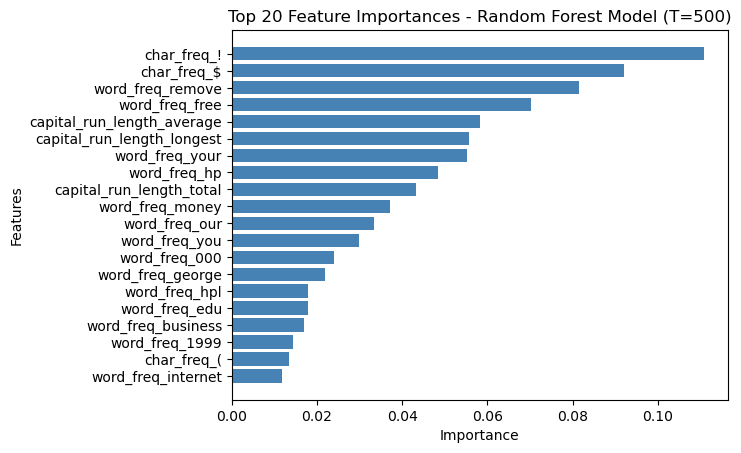

In [ ]:
''' 
    Part 3
    Compute the variable importance for each feature and include a plot.
'''
# load feature names from spambase.names
with open("spambase/spambase.names", "r") as file:
    lines = file.readlines()

feature_names = []
for line in lines:
    if "continuous" in line and "|" not in line:
        feature_names.append(line.split(":")[0].strip())

# make random forest model with T = 500 (using the T that performed the best - said in a Piazza post)
model_500 = RandomForestClassifier(n_estimators = 500, random_state = 5)
model_500.fit(X_train, y_train)

# get the feature importances from the model
importances = model_500.feature_importances_

# make a dataframe that has all the features and their importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending = False)

# print the top 20 variables importances - said in a Piazza post
print("Top 20 Variable Importances:")
print(importance_df.head(20).to_string(index=False))

# plot top 20 - said in a Piazza post
top_20 = importance_df.head(20)
plt.barh(top_20['Feature'], top_20['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel("Features")
plt.title('Top 20 Feature Importances - Random Forest Model (T=500)')
plt.show()